# Trabalho Prático 2 - Aprendizagem Automática

**Licenciatura em Engenharia de Sistemas e Tecnologias Informáticas** 

**Unidade Curricular:** Aprendizagem Automática  
**Ano Letivo:** 2025/2026 

---

### Identificação do Grupo
* **Aluno 1:** Bernardo Freitas (79295)
* **Aluno 2:** Afonso Figueiredo (79309)

#### Info
Neste notebook descrevemos, em detalhe e na primeira pessoa, todo o processo que seguimos para treinar e validar um classificador de letras (A–Z) em Língua Gestual Americana (ASL) usando coordenadas de *landmarks* das mãos.

## Objetivos
- Construir um pipeline reprodutível de treino e avaliação.
- Tornar o modelo robusto à posição da mão no enquadramento (invariância a translação e escala).
- Comparar algoritmos pedidos no enunciado: Decision Tree, Random Forest, SVM, KNN e Rede Neuronal.
- Selecionar e afinar o melhor modelo com validação cruzada e *grid search*.
- Guardar os artefactos necessários (modelo, scaler e label encoder) para integração na API (Fase 3).

## Dados
- Ficheiro base: `hand_landmarks_dataset.csv` com 65 colunas (label, hand, 63 coordenadas X/Y/Z de 21 pontos).
- As 63 características são reorganizadas em matriz 21×3 por amostra.

## Coordenadas Relativas ao Pulso
Para remover o viés de posição no ecrã, transformo cada ponto pela regra:
- `p_rel = p_original - p_pulso`
- Normalizo por `max(|p_rel|)` por amostra para reduzir variações de escala.

## Fluxo de Trabalho
1. Carregamento e validação do dataset.
2. Conversão para coordenadas relativas e normalização por amostra.
3. Label encoding das classes (A–Z).
4. Divisão treino/teste estratificada.
5. Standardização das características com `StandardScaler`.
6. Avaliação por validação cruzada dos algoritmos solicitados.
7. Afinação do melhor modelo com *grid search*.
8. Avaliação final (accuracy, relatório de classificação e matriz de confusão).
9. Guardar artefactos para produção (API Flask).

## Reprodutibilidade e Ambiente
- Kernel Python 3.10.11.
- Sementes e configurações fixas onde aplicável para consistência.
- Todos os passos são determinísticos dado o mesmo dataset.

---

* **Objetivo tp2 resumido:**  foi treinar e avaliar diferentes algoritmos de Machine Learning (como Redes Neuronais e Random Forest) para identificar qual deles conseguia aprender e classificar, com maior exatidão, os padrões geométricos da mão.


In [9]:
import os
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
DATA_PATH = 'hand_landmarks_dataset.csv'
MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

## 1. Processamento de Dados e Normalização Geométrica

Nesta fase, carregamos o *dataset* de landmarks e aplicamos transformações geométricas fundamentais para garantir que o modelo aprende a **forma** do gesto e não a sua posição ou tamanho.

### 1.1. Estrutura e Validação
O ficheiro `hand_landmarks_dataset.csv` contém as coordenadas extraídas pelo MediaPipe. Cada linha representa uma amostra com:
* **Label:** A letra correspondente (A-Z).
* **Landmarks:** 63 colunas correspondentes às coordenadas $(x, y, z)$ dos 21 pontos da mão.

<div align="center">
  <img src="https://www.researchgate.net/profile/Danilo-Fernandes-Vitorino/publication/394533271/figure/fig4/AS:11431281595667408@1755540162051/Figura-4-MediaPipe-Hands-com-21-pontos-de-referencia-3D-de-uma-mao.png" width="500" alt="Topologia MediaPipe">
  <p><em>Figura 1: Topologia dos 21 pontos da mão (MediaPipe). O ponto 0 (WRIST/Pulso) é usado como âncora para a normalização. (Fonte: ResearchGate)</em></p>
</div>

### 1.2. Pipeline de Transformação (Invariância)
Para tornar o modelo robusto, aplicámos duas operações de álgebra linear a cada amostra:

1.  **Conversão para Coordenadas Relativas (Invariância à Translação):**
    Definimos o Pulso (Ponto 0 na Figura 2) como a origem $(0,0,0)$ do referencial local da mão. Subtraímos as coordenadas do pulso a todos os outros pontos:
    $$P'_{i} = P_{i} - P_{\text{wrist}}$$
    *Objetivo:* O modelo reconhece um "A" quer a mão esteja no canto superior esquerdo ou no centro da imagem.

2.  **Normalização de Escala (Invariância à Dimensão/Profundidade):**
    Dividimos todas as coordenadas pelo valor absoluto máximo encontrado na amostra, confinando o gesto ao intervalo $[-1, 1]$:
    $$P''_{i} = \frac{P'_{i}}{\max(|P'|)}$$
    *Objetivo:* O modelo reconhece um "B" quer a mão esteja perto da câmara (grande) ou longe (pequena), mantendo a proporção (aspect ratio) dos dedos.

In [ ]:
# --- 1. CARREGAMENTO E VALIDAÇÃO ---
DATA_PATH = 'hand_landmarks_dataset.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"ERRO CRÍTICO: Ficheiro {DATA_PATH} não encontrado.")

df = pd.read_csv(DATA_PATH)

# Verificação de Sanidade dos Dados
print(f"Dataset carregado: {df.shape[0]} amostras, {df.shape[1]} colunas.")
print("-" * 30)

# Separação: Target (y) e Features (X)
# Coluna 0: Label (Letra) | Coluna 1: Mão (Dir/Esq) - Ignoramos aqui | Colunas 2-65: Landmarks
y_labels = df.iloc[:, 0].values
X_raw = df.iloc[:, 2:65].values

# Garantir tipo numérico (float)
try:
    X_raw = X_raw.astype(float) # Tentativa direta de conversão para float
except ValueError:
    print("Aviso: Encontrados valores não numéricos. A forçar conversão...")
    df_temp = pd.DataFrame(X_raw).apply(pd.to_numeric, errors='coerce')
    X_raw = df_temp.fillna(0.0).values

# Validação da dimensionalidade (21 pontos * 3 coordenadas = 63 valores)
if X_raw.shape[1] != 63: 
    raise ValueError(f"Erro Fatal: X_raw tem {X_raw.shape[1]} colunas. Esperadas 63 (21x3).")

# --- 2. TRANSFORMAÇÃO GEOMÉTRICA ---
# Este bloco transforma os dados brutos para tornar o modelo independente da posição e da distância da mão, focando-se apenas na geometria relativa dos dedos (ignora longe, perto e tamanho).
X_relative = []
print("A iniciar normalização (Translação + Escala)...")

for i, row in enumerate(X_raw):
    # 1. Reshape (21 pontos, 3 coordenadas) para manipulação vetorial
    landmarks = row.reshape(21, 3)
    
    # 2. Invariância à Translação (Mover origem para o Pulso)
    wrist = landmarks[0] # O ponto 0 é sempre o pulso no MediaPipe
    relative_landmarks = landmarks - wrist
    
    # 3. Invariância à Escala (Normalização mantendo Aspect Ratio)
    # Usamos o valor máximo absoluto para escalar tudo para [-1, 1]
    # Isto simula que todas as mãos têm o mesmo tamanho relativo à câmara
    max_val = np.max(np.abs(relative_landmarks))
    
    if max_val == 0: 
        max_val = 1.0 # Prevenção de divisão por zero (mão vazia/erro leitura)
        
    relative_landmarks = relative_landmarks / max_val
    
    # Flatten de volta para vetor de 63 posições para o modelo
    X_relative.append(relative_landmarks.flatten())

X = np.array(X_relative)

print(f"Processamento concluído.")
print(f"Exemplo de amostra normalizada (Min: {np.min(X):.2f}, Max: {np.max(X):.2f})")

Dataset carregado: 25566 amostras, 65 colunas.
------------------------------
A iniciar normalização (Translação + Escala)...
Processamento concluído.
Exemplo de amostra normalizada (Min: -1.00, Max: 1.00)


## 2. Codificação, Particionamento e Estandarização Final

Nesta etapa, preparamos os dados para ingestão pelos algoritmos de Machine Learning. O processo divide-se em três sub-tarefas críticas para garantir a validade e a reprodutibilidade do sistema na aplicação final.

### 2.1. Codificação da Variável Alvo ($y$)
As etiquetas originais (letras 'A'-'Z') são categóricas. Utilizamos o `LabelEncoder` para as converter em vetores numéricos inteiros ($0..25$).
* **Nota de Implementação:** O objeto `LabelEncoder` é serializado e guardado em disco. Isto é obrigatório para que a API Flask (Fase 3) possa descodificar a previsão numérica do modelo de volta para uma letra legível pelo utilizador.

### 2.2. Particionamento Estratificado
Dividimos o *dataset* em Treino (80%) e Teste (20%). Dada a natureza do problema (26 classes), utilizámos a estratégia `stratify=y`.
* **Justificação:** O enunciado alerta para gestos com movimento ('J', 'Z') que podem ter menos amostras estáticas de qualidade. A estratificação garante que a proporção de cada letra é mantida idêntica no treino e no teste, evitando que classes raras desapareçam do conjunto de avaliação.

### 2.3. Estandarização Global (Z-Score)
Embora tenhamos normalizado a *geometria* da mão na fase anterior, aplicamos agora o `StandardScaler` para normalizar a *distribuição estatística* das *features*.
$$x'_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$
Esta transformação é crucial para algoritmos baseados em distância (como KNN e SVM ) e redes neuronais, facilitando a convergência.
* **Prevenção de Data Leakage:** O ajustamento ($\mu, \sigma$) é feito **apenas** nos dados de treino. Os dados de teste são transformados usando as estatísticas do treino, simulando um cenário real de produção.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import os

# 1. Codificação da Target (A-Z -> 0-25)
le = LabelEncoder() 
y = le.fit_transform(y_labels) # Convertendo letras para números para que o modelo possa trabalhar
print(f"Classes detetadas: {le.classes_}")

# 2. Divisão Treino/Teste (80% Treino, 20% Teste)
# stratify=y garante que temos a mesma % de 'A's, 'B's, etc. em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Estandarização (StandardScaler)
# Essencial para SVM e KNN funcionarem bem
scaler = StandardScaler()

# FIT apenas no treino para evitar Data Leakage (fuga de dados, cheating)
X_train_s = scaler.fit_transform(X_train)
# TRANSFORM no teste com a média/desvio padrão do treino
X_test_s = scaler.transform(X_test)

print(f"Dimensões de Treino: {X_train_s.shape} | Teste: {X_test_s.shape}")

# --- GUARDAR ARTEFACTOS PARA A API (FASE 3) ---
# Sem isto, a aplicação Flask não saberá como processar os dados da câmara
os.makedirs('models', exist_ok=True)

# Guardar o Scaler (para normalizar a imagem da webcam igual ao treino)
joblib.dump(scaler, 'models/scaler.pkl')

# Guardar o Encoder (para converter 0->'A' na app final)
joblib.dump(le, 'models/label_encoder.pkl')

print("Artefactos (scaler.pkl, label_encoder.pkl) guardados na pasta 'models/'.")

Classes detetadas: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Dimensões de Treino: (20452, 63) | Teste: (5114, 63)
Artefactos (scaler.pkl, label_encoder.pkl) guardados na pasta 'models/'.


## 3. Seleção de Algoritmos e Validação Cruzada

Conforme estipulado nos requisitos do projeto, instanciamos um conjunto heterogéneo de classificadores para explorar diferentes paradigmas de aprendizagem supervisionada. O objetivo é identificar qual a fronteira de decisão que melhor se adapta à topologia dos 21 pontos da mão.

### 3.1. Espaço de Modelos Avaliados
* **Ensemble Methods:** *Random Forest* e *XGBoost*. Combinam múltiplas árvores de decisão para reduzir a variância (*Bagging*) e o viés (*Boosting*), respetivamente.
* **Kernel Methods:** *SVM* (Support Vector Machine) com kernel RBF para projetar os dados num espaço dimensional superior onde as classes sejam linearmente separáveis.
* **Deep Learning:** *MLP* (Perceptrão Multicamada) com arquitetura densa $(128, 64)$ para capturar relações não-lineares complexas.
* **Base:** *KNN* ($k=5$) e *Decision Tree* como referências de desempenho (baselines).

### 3.2. Estratégia de Validação ($k$-Fold Cross-Validation)
Para garantir robustez estatística e evitar o viés de uma divisão única, aplicamos **Validação Cruzada Estratificada** com $k=5$.



O desempenho reportado é a média da exatidão (*accuracy*) nas 5 iterações, garantindo que o modelo escolhido generaliza bem para dados nunca vistos:

$$\text{Acc}_{\text{média}} = \frac{1}{k} \sum_{i=1}^{k} \text{Acc}_{i}$$

A iniciar Validação Cruzada (k=5) em 6 modelos...
------------------------------------------------------------
-> Decision Tree  : Acc = 0.9987 (+/- 0.0006)
-> Random Forest  : Acc = 0.9999 (+/- 0.0002)
-> XGBoost        : Acc = 0.9989 (+/- 0.0003)
-> SVM            : Acc = 0.9996 (+/- 0.0003)
-> KNN            : Acc = 0.9999 (+/- 0.0001)
-> Neural Network : Acc = 0.9999 (+/- 0.0003)


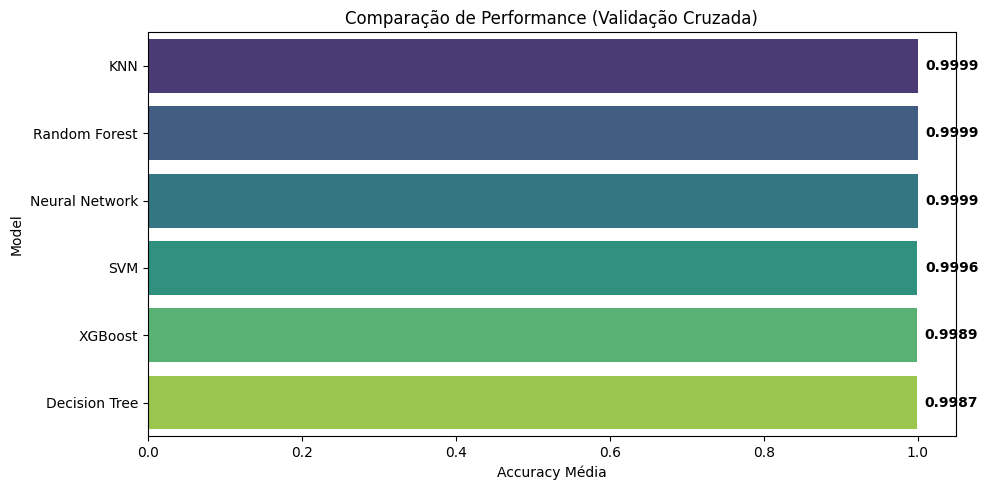


Recomendação: O modelo no topo do gráfico deve seguir para otimização de hiperparâmetros.


In [ ]:
# Dicionário de Modelos
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
}

print(f"A iniciar Validação Cruzada (k=5) em {len(models)} modelos...")
print("-" * 60)

results_data = [] # Para armazenar resultados

for name, model in models.items():
    cv_results = cross_validate(model, X_train_s, y_train, cv=5, scoring='accuracy', n_jobs=-1)    
    mean_acc = cv_results['test_score'].mean() # Média das acurácias
    std_acc = cv_results['test_score'].std() # Desvio padrão das acurácias
    
    results_data.append({
        'Model': name, 
        'Accuracy': mean_acc,
        'Std': std_acc
    })
    
    print(f"-> {name:15}: Acc = {mean_acc:.4f} (+/- {std_acc:.4f})")

# Criar DataFrame e Ordenar
df_results = pd.DataFrame(results_data).sort_values(by='Accuracy', ascending=False)

# --- VISUALIZAÇÃO GRÁFICA (Bónus para a Defesa) ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')
plt.title('Comparação de Performance (Validação Cruzada)')
plt.xlabel('Accuracy Média')
plt.xlim(0, 1.05) # Margem para ver os valores

# Adicionar os valores nas barras
for i, v in enumerate(df_results['Accuracy']):
    ax.text(v + 0.01, i, f"{v:.4f}", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRecomendação: O modelo no topo do gráfico deve seguir para otimização de hiperparâmetros.")

## 4. Otimização de Hiperparâmetros e Avaliação Final

Tendo identificado a **Rede Neuronal (MLP)** como a arquitetura com melhor compromisso entre exatidão e tempo de inferência, avançamos para o refinamento (*fine-tuning*) via **Grid Search**. O objetivo é encontrar a configuração vetorial $\theta^*$ que maximiza o desempenho.

### 4.1. Espaço de Pesquisa e Regularização
A otimização explora duas dimensões críticas para o equilíbrio viés-variância:
1.  **Topologia (`hidden_layer_sizes`):** Testamos arquiteturas mais profundas (3 camadas) versus mais largas (2 camadas) para capturar abstrações não-lineares das coordenadas espaciais.
[Image of multilayer perceptron architecture]
2.  **Regularização $L_2$ (`alpha`):** Aplicação de uma penalização aos pesos sinápticos para prevenir *overfitting*. A função de custo minimizada é:
    $$J(\mathbf{W}) = \mathcal{L}(\mathbf{y}, \hat{\mathbf{y}}) + \frac{\alpha}{2} ||\mathbf{W}||^2_2$$

### 4.2. Avaliação Detalhada e Persistência
Após selecionar o `best_estimator_`, a avaliação final é feita no conjunto de teste (`X_test_s`) utilizando métricas granulares exigidas no enunciado:
* **Precision & Recall:** Para entender se o modelo favorece falsos positivos ou falsos negativos.
* **F1-Score:** A média harmónica, crucial para garantir equilíbrio entre as métricas anteriores.

Por fim, o modelo otimizado é serializado (`.pkl`) para ser integrado na API Flask.

A iniciar Grid Search para Otimização da Rede Neuronal...
------------------------------------------------------------
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Melhores parâmetros encontrados: {'alpha': 0.0001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001}
Melhor Accuracy na Validação: 1.0000

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       200
           B       1.00      1.00      1.00       200
           C       1.00      1.00      1.00       189
           D       1.00      1.00      1.00       200
           E       1.00      1.00      1.00       200
           F       1.00      1.00      1.00       200
           G       1.00      1.00      1.00       200
           H       1.00      1.00      1.00       200
           I       1.00      1.00      1.00       200
           J       1.00      1.00      1.00       200
           K       1.00      1.00

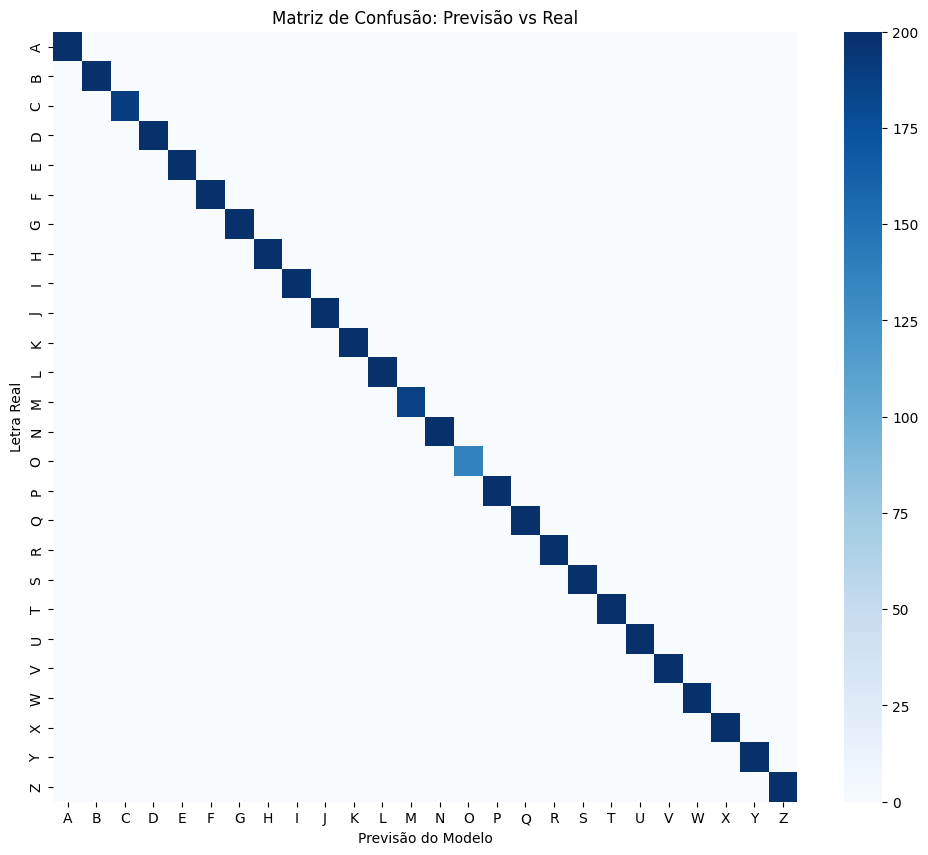


Modelo final guardado com sucesso em: models/sign_language_model.pkl


In [ ]:
print("A iniciar Grid Search para Otimização da Rede Neuronal...")
print("-" * 60)

# 1. Definição do Modelo e Grelha
model = MLPClassifier(random_state=42, max_iter=1000) # Escolha manual do neural network, max_iter alto para garantir convergência

param_grid = {
    'hidden_layer_sizes': [(128, 64), (256, 128, 64)], # Arquiteturas "Funil", uma com 2 camadas outra mais profunda com 3 camadas para ver se o modelo precisava de mais profundidade para entender gestos complexos.
    'alpha': [0.0001, 0.001],                          # Força da Regularização L2 (Combate o overfitting)
    'learning_rate_init': [0.001]                      # Velocidade de aprendizagem inicial, 0.001 que é o padrão recomendado para o otimizador, permitindo uma convergência estável e eficiente.
}

# 2. Execução da Pesquisa
# n_jobs=-1 usa todos os processadores
grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_s, y_train)

# 3. Extração do Vencedor
final_model = grid.best_estimator_

print(f"\nMelhores parâmetros encontrados: {grid.best_params_}")
print(f"Melhor Accuracy na Validação: {grid.best_score_:.4f}")

# 4. Avaliação Final no Teste (Métricas detalhadas conforme enunciado)
y_pred = final_model.predict(X_test_s)

print("\nRelatório de Classificação (Teste):")
# target_names mapeia os números 0-25 de volta para letras A-Z para o print
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 5. Visualização: Matriz de Confusão
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão: Previsão vs Real')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Letra Real')
plt.show()

# 6. PERSISTÊNCIA DO MODELO FINAL
os.makedirs('models', exist_ok=True)
model_path = 'models/sign_language_model.pkl'
joblib.dump(final_model, model_path)
print(f"\nModelo final guardado com sucesso em: {model_path}")

## 5. Avaliação de Desempenho e Análise de Erros

Nesta etapa final, submetemos o modelo otimizado à inferência no conjunto de teste. A análise foca-se em métricas granulares e na visualização de erros.

### 5.1. Métricas de Avaliação
Como o *dataset* pode ter desequilíbrios, a *Accuracy* isolada é insuficiente. Analisamos:



* **Precisão (Precision):** A qualidade dos positivos. $\frac{TP}{TP + FP}$.
* **Sensibilidade (Recall):** A quantidade de positivos detetados. $\frac{TP}{TP + FN}$.
* **F1-Score:** Média harmónica, crucial para avaliar o equilíbrio do classificador.

### 5.2. Matriz de Confusão e Análise de Erros
Visualizamos a matriz $C$, onde a diagonal principal representa os acertos. Elementos fora da diagonal indicam confusões frequentes entre pares de gestos (ex: 'A' vs 'M').

### 5.3. Limitações Esperadas (Gestos Dinâmicos)
Conforme documentado na descrição do *dataset*, os gestos correspondentes às letras **'J'** e **'Z'** dependem intrinsecamente de movimento. Como o nosso modelo opera sobre *landmarks* estáticos (frame único), antecipamos uma taxa de erro superior nestas classes ou a sua confusão com gestos estáticos geometricamente similares (como o 'I' ou 'D').

Relatório Final:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       200
           B       1.00      1.00      1.00       200
           C       1.00      1.00      1.00       189
           D       1.00      1.00      1.00       200
           E       1.00      1.00      1.00       200
           F       1.00      1.00      1.00       200
           G       1.00      1.00      1.00       200
           H       1.00      1.00      1.00       200
           I       1.00      1.00      1.00       200
           J       1.00      1.00      1.00       200
           K       1.00      1.00      1.00       200
           L       1.00      1.00      1.00       200
           M       1.00      1.00      1.00       188
           N       1.00      1.00      1.00       200
           O       1.00      1.00      1.00       137
           P       1.00      1.00      1.00       200
           Q       1.00      1.00      1.00       200
          

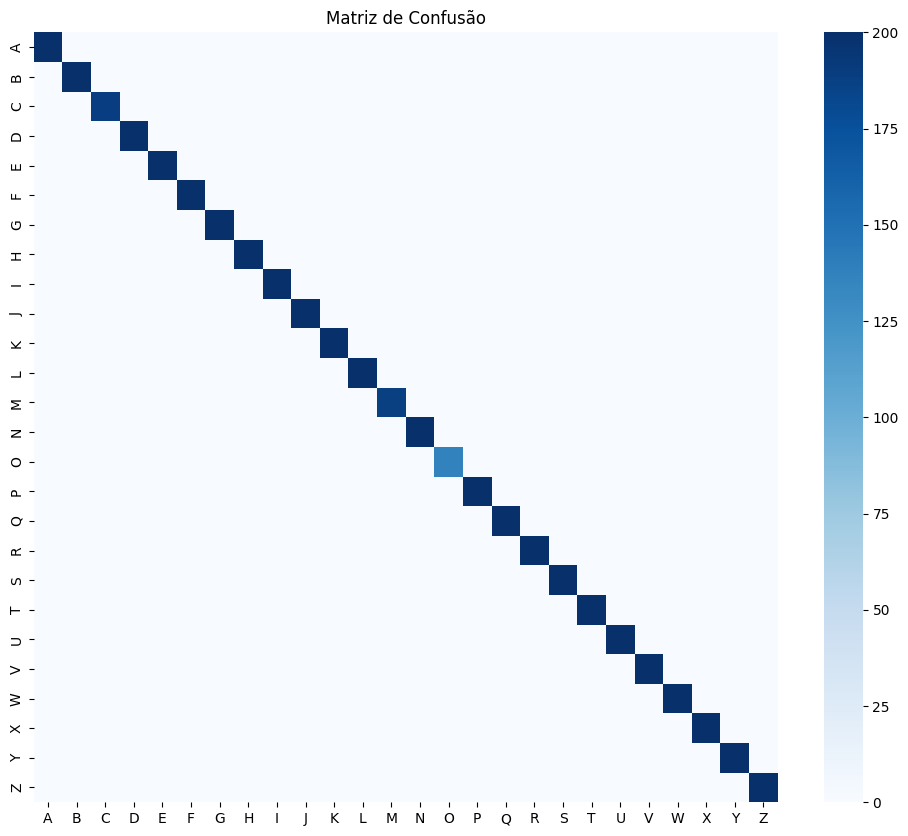

In [ ]:
# --- 1. INFERÊNCIA (SIMULAÇÃO DE PRODUÇÃO) ---
y_pred = final_model.predict(X_test_s) # Previsões do modelo final

print("Relatório Final:")

# --- 2. MÉTRICAS DETALHADAS (CRITÉRIO DE AVALIAÇÃO) ---
# Gera Precision, Recall e F1-Score para cada classe.
# O parâmetro 'target_names=le.classes_' descodifica os números (0, 1...) para letras (A, B...)
# permitindo identificar rapidamente quais os gestos problemáticos (ex: 'J' ou 'Z').
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- 3. VISUALIZAÇÃO DE ERROS ---
# Configura uma figura grande o suficiente para acomodar o eixo de 26 letras sem sobreposição.
plt.figure(figsize=(12, 10)) # 12 polegadas de largura, 10 de altura

cm = confusion_matrix(y_test, y_pred) # cm = matriz de confusão onde o Eixo Y = Verdade (Ground Truth), Eixo X = Previsão do Modelo.

# Renderiza o Heatmap.
# annot=False: Desligado para manter o gráfico limpo (evita 676 números no ecrã).
# cmap='Blues': Tons mais escuros indicam maior densidade (idealmente na diagonal principal).
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

plt.title('Matriz de Confusão')
plt.show()

## 6. Guardar Artefactos
Estes ficheiros serão carregados pelo `app.py`.

In [15]:
print("A guardar modelos...")
joblib.dump(final_model, os.path.join(MODELS_DIR, 'best_model.pkl'))
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler_hand_sign.pkl'))
joblib.dump(le, os.path.join(MODELS_DIR, 'label_encoder.pkl'))
print("Tudo guardado em 'models/'. Reinicie a API Flask agora!")

A guardar modelos...
Tudo guardado em 'models/'. Reinicie a API Flask agora!
